<a href="https://colab.research.google.com/github/Phalguni-dhabale/MV-LAB/blob/main/MV_PRACTICAL_4_D3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [9]:
from google.colab import files

uploaded = files.upload()

Saving metal.jpg to metal.jpg


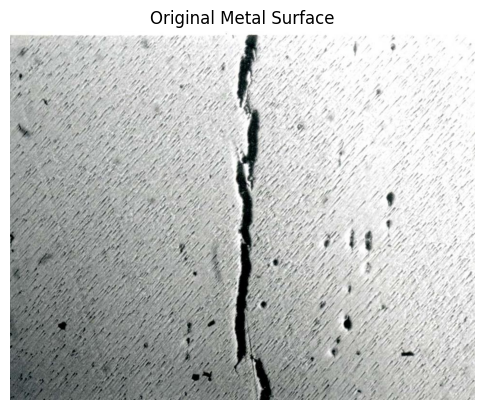

In [10]:
image = cv2.imread("metal.jpg")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(image_rgb)
plt.title("Original Metal Surface")
plt.axis("off")
plt.show()

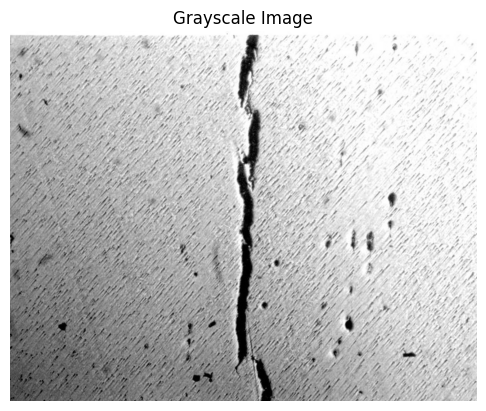

In [11]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray,cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

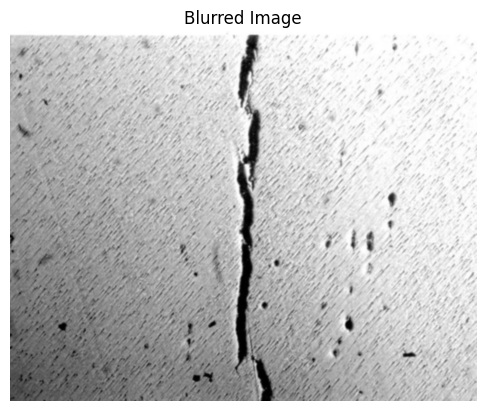

In [12]:
blur = cv2.GaussianBlur(gray,(5,5),0)

plt.imshow(blur,cmap='gray')
plt.title("Blurred Image")
plt.axis("off")
plt.show()

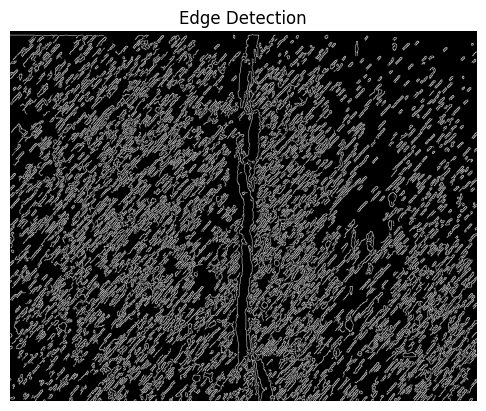

In [13]:
edges = cv2.Canny(blur,50,150)

plt.imshow(edges,cmap='gray')
plt.title("Edge Detection")
plt.axis("off")
plt.show()

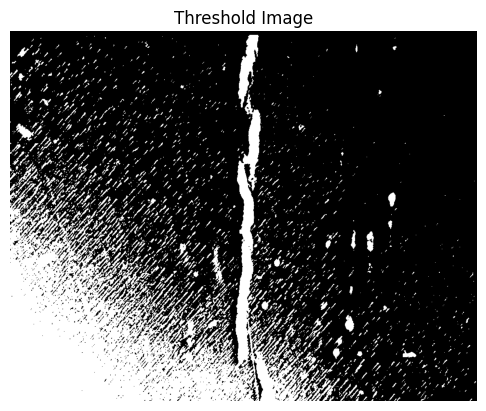

In [14]:
_,thresh=cv2.threshold(gray,150,255,cv2.THRESH_BINARY_INV)

plt.imshow(thresh,cmap='gray')
plt.title("Threshold Image")
plt.axis("off")
plt.show()

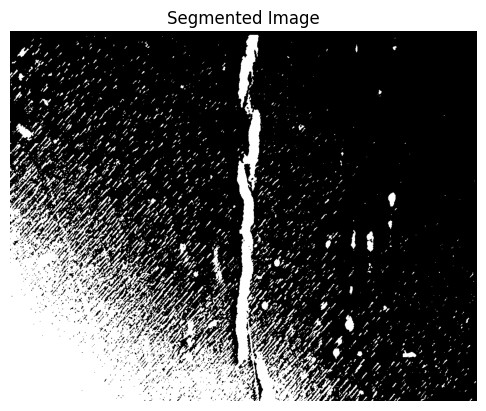

In [15]:
segmented = thresh.copy()

plt.imshow(segmented,cmap='gray')
plt.title("Segmented Image")
plt.axis("off")
plt.show()

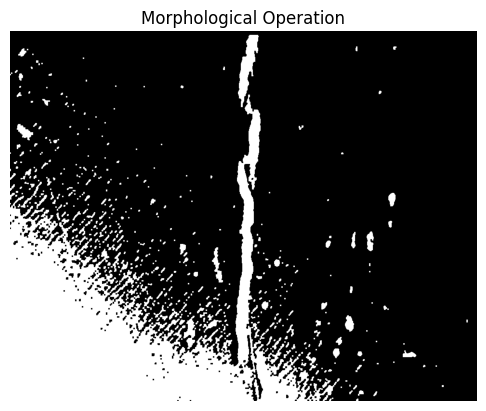

In [16]:
kernel=np.ones((3,3),np.uint8)

opening=cv2.morphologyEx(segmented,cv2.MORPH_OPEN,kernel)

closing=cv2.morphologyEx(opening,cv2.MORPH_CLOSE,kernel)

plt.imshow(closing,cmap='gray')
plt.title("Morphological Operation")
plt.axis("off")
plt.show()

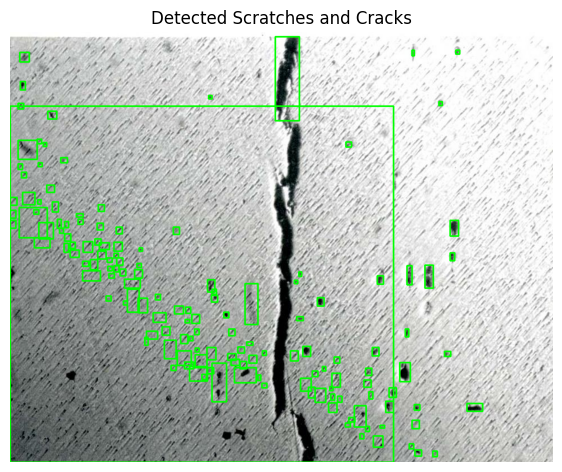

In [17]:
contours,_=cv2.findContours(closing,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

output=image.copy()

for cnt in contours:
    area=cv2.contourArea(cnt)

    if area>20:
        x,y,w,h=cv2.boundingRect(cnt)
        cv2.rectangle(output,(x,y),(x+w,y+h),(0,255,0),2)

output_rgb=cv2.cvtColor(output,cv2.COLOR_BGR2RGB)

plt.figure(figsize=(7,7))
plt.imshow(output_rgb)
plt.title("Detected Scratches and Cracks")
plt.axis("off")
plt.show()

In [18]:
count=0

for cnt in contours:
    if cv2.contourArea(cnt)>20:
        count+=1

print("Total Defects Detected:",count)

Total Defects Detected: 148
